In [1]:
!python --version


Python 3.12.10


In [1]:
import pandas as pd

In [2]:
store = pd.read_csv('store.csv')
train = pd.read_csv('train.csv',low_memory=False)
test = pd.read_csv('test.csv')

In [3]:
test

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0
...,...,...,...,...,...,...,...,...
41083,41084,1111,6,2015-08-01,1.0,0,0,0
41084,41085,1112,6,2015-08-01,1.0,0,0,0
41085,41086,1113,6,2015-08-01,1.0,0,0,0
41086,41087,1114,6,2015-08-01,1.0,0,0,0


In [4]:
df = train.merge(store,how='left',on='Store')

In [49]:
df

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017204,1111,2,2013-01-01,0,0,0,0,a,1,a,a,1900.0,6.0,2014.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct"
1017205,1112,2,2013-01-01,0,0,0,0,a,1,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1017206,1113,2,2013-01-01,0,0,0,0,a,1,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1017207,1114,2,2013-01-01,0,0,0,0,a,1,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [5]:
test_df = test.merge(store,how='left',on='Store')

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isna().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

In [8]:
df['Date']=pd.to_datetime(df.Date)

In [9]:
test_df['Date']=pd.to_datetime(test_df.Date)

In [10]:
df.Date.min(),df.Date.max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2015-07-31 00:00:00'))

In [11]:
test_df.Date.min(),test_df.Date.max()

(Timestamp('2015-08-01 00:00:00'), Timestamp('2015-09-17 00:00:00'))

In [12]:
df = df[df.Open==1].copy()

In [13]:
import seaborn as sns

<Axes: xlabel='Sales', ylabel='Count'>

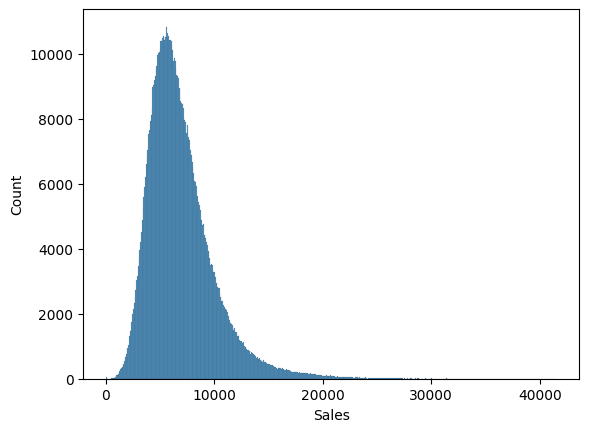

In [14]:
sns.histplot(data=df,x='Sales')

<Axes: xlabel='Customers', ylabel='Sales'>

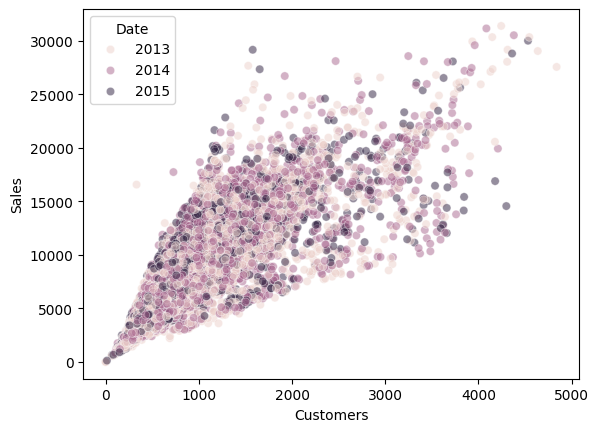

In [17]:
sns.scatterplot(data=temp,x=temp.Customers,y=temp.Sales,hue=temp.Date.dt.year,alpha=0.5)

<Axes: xlabel='Sales', ylabel='Count'>

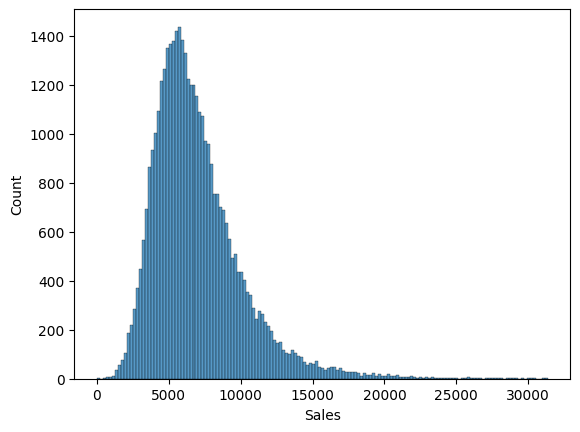

In [16]:
temp = df.sample(40000)
sns.histplot(data=temp,x=temp.Sales)

<Axes: xlabel='Sales', ylabel='Store'>

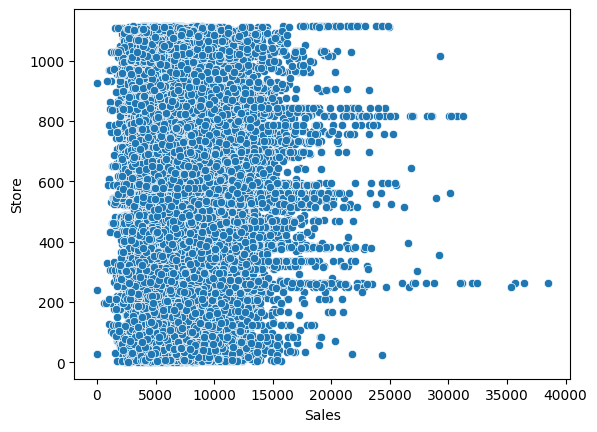

In [81]:
sns.scatterplot(data=temp,x=temp.Sales,y=temp.Store)

In [18]:
df['Day']=df.Date.dt.day
df['Month']=df.Date.dt.month
df['Year']=df.Date.dt.year

In [19]:
test_df['Day']=df.Date.dt.day
test_df['Month']=df.Date.dt.month
test_df['Year']=df.Date.dt.year

In [20]:
df.columns

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval', 'Day', 'Month', 'Year'],
      dtype='object')

<Axes: xlabel='Month', ylabel='Sales'>

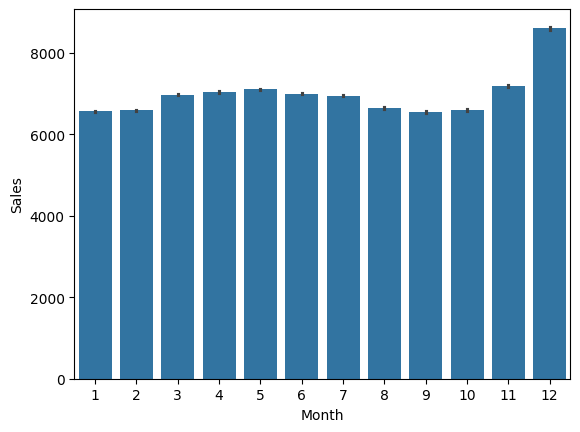

In [21]:
sns.barplot(data=df,x='Month',y='Sales')

In [24]:
test_size = int(.75*len(df))
sort = df.sort_values('Date')
train_df,val_df = sort[:test_size],sort[test_size:]

In [26]:
input_col = ['Store', 'DayOfWeek', 'Promo','StateHoliday','StoreType', 'Assortment','Day', 'Month', 'Year']
target_col = 'Sales'

In [31]:
train_target = train_df[target_col]
val_target = val_df[target_col]
train_target.value_counts

<bound method IndexOpsMixin.value_counts of 1017190     5961
1016179     4220
1016353     6851
1016356    17267
1016368     3102
           ...  
256632      6897
256642     15736
256634      7444
256633      5207
256636      3587
Name: Sales, Length: 633294, dtype: int64>

In [32]:
train_df.Date.min(),train_df.Date.max()

(Timestamp('2013-01-01 00:00:00'), Timestamp('2014-12-10 00:00:00'))

In [33]:
val_df.Date.min(),val_df.Date.max()

(Timestamp('2014-12-10 00:00:00'), Timestamp('2015-07-31 00:00:00'))

In [34]:
df[input_col].nunique()

Store           1115
DayOfWeek          7
Promo              2
StateHoliday       4
StoreType          4
Assortment         3
Day               31
Month             12
Year               3
dtype: int64

In [35]:
num_col = ['Store','Day', 'Month', 'Year']
cat_col = ['DayOfWeek', 'StateHoliday','Promo','StoreType', 'Assortment']

In [36]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')

In [37]:
imputer.fit(train_df[num_col])

,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [38]:
train_df[num_col]=imputer.transform(train_df[num_col])
val_df[num_col]=imputer.transform(val_df[num_col])
test_df[num_col]=imputer.transform(test_df[num_col])


C:\Users\arrav\AppData\Local\Temp\ipykernel_17144\771149876.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[num_col]=imputer.transform(train_df[num_col])
C:\Users\arrav\AppData\Local\Temp\ipykernel_17144\771149876.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df[num_col]=imputer.transform(val_df[num_col])


In [39]:
test_df[num_col].isna().sum()

Store    0
Day      0
Month    0
Year     0
dtype: int64

In [40]:
from sklearn.preprocessing import MinMaxScaler

In [41]:
scaler = MinMaxScaler()

In [42]:
scaler.fit(train_df[num_col])

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [43]:
train_df[num_col] = scaler.transform(train_df[num_col])

C:\Users\arrav\AppData\Local\Temp\ipykernel_17144\84383044.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[num_col] = scaler.transform(train_df[num_col])


In [44]:
train_df[num_col].describe()

,Store,Day,Month,Year
count,633294.000000,633294.000000,633294.000000,633294.000000
mean,0.500437,0.488868,0.478522,0.466373
std,0.288786,0.290426,0.306317,0.498868
min,0.000000,0.000000,0.000000,0.000000
25%,0.251346,0.233333,0.181818,0.000000
50%,0.500000,0.500000,0.454545,0.000000
75%,0.750449,0.733333,0.727273,1.000000
max,1.000000,1.000000,1.000000,1.000000


In [45]:
from sklearn.preprocessing import OneHotEncoder


In [46]:
encoder = OneHotEncoder(sparse_output=False,handle_unknown='ignore')

In [47]:
encoder.fit(train_df[cat_col])

,categories,'auto'
,drop,None
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [48]:
encoded_col = encoder.get_feature_names_out(cat_col).tolist()

In [49]:
encoded_col

['DayOfWeek_1',
 'DayOfWeek_2',
 'DayOfWeek_3',
 'DayOfWeek_4',
 'DayOfWeek_5',
 'DayOfWeek_6',
 'DayOfWeek_7',
 'StateHoliday_0',
 'StateHoliday_a',
 'StateHoliday_b',
 'StateHoliday_c',
 'Promo_0',
 'Promo_1',
 'StoreType_a',
 'StoreType_b',
 'StoreType_c',
 'StoreType_d',
 'Assortment_a',
 'Assortment_b',
 'Assortment_c']

In [50]:
train_df[encoded_col] = encoder.transform(train_df[cat_col])
val_df[encoded_col] = encoder.transform(val_df[cat_col])
test_df[encoded_col] = encoder.transform(test_df[cat_col])

C:\Users\arrav\AppData\Local\Temp\ipykernel_17144\1995766843.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[encoded_col] = encoder.transform(train_df[cat_col])
C:\Users\arrav\AppData\Local\Temp\ipykernel_17144\1995766843.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[encoded_col] = encoder.transform(train_df[cat_col])
C:\Users\arrav\AppData\Local\Temp\ipykernel_17144\1995766843.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try u

In [70]:
from sklearn.metrics import mean_squared_error
?mean_squared_error

Signature:
mean_squared_error(
    y_true,
    y_pred,
    *,
    sample_weight=None,
    multioutput='uniform_average',
)
Docstring:
Mean squared error regression loss.

Read more in the :ref:`User Guide <mean_squared_error>`.

Parameters
----------
y_true : array-like of shape (n_samples,) or (n_samples, n_outputs)
    Ground truth (correct) target values.

y_pred : array-like of shape (n_samples,) or (n_samples, n_outputs)
    Estimated target values.

sample_weight : array-like of shape (n_samples,), default=None
    Sample weights.

multioutput : {'raw_values', 'uniform_average'} or array-like of shape             (n_outputs,), default='uniform_average'
    Defines aggregating of multiple output values.
    Array-like value defines weights used to average errors.

    'raw_values' :
        Returns a full set of errors in case of multioutput input.

    'uniform_average' :
        Errors of all outputs are averaged with uniform weight.

Returns
-------
loss : float or array of flo

In [55]:
x_train = train_df[num_col+encoded_col]
x_val = val_df[num_col+encoded_col]
x_test = test_df[num_col+encoded_col]

In [73]:
def model_selection(model):
    model.fit(x_train,train_target)
    t_pre = model.predict(x_train)
    v_pre = model.predict(x_val)
    train_l = mean_squared_error(t_pre,train_target,multioutput='uniform_average')
    val_l = mean_squared_error(v_pre,val_target,sample_weight=None)
    return train_l,val_l


In [74]:
from sklearn.linear_model import LinearRegression
model_selection(LinearRegression())

(7516300.3308810275, 73755851639.20079)

<bound method IndexOpsMixin.value_counts of 256637     3720
256638     4258
256639     7170
256640     7359
256635     4579
          ...  
744        8363
745        9082
746       10708
740       11253
0          5263
Name: Sales, Length: 211098, dtype: int64>